<a href="https://colab.research.google.com/github/NiranjanHebli/cat-vs-astronaut-cnn/blob/main/cat_using_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
%pip install torch torchvision matplotlib pillow

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, transform

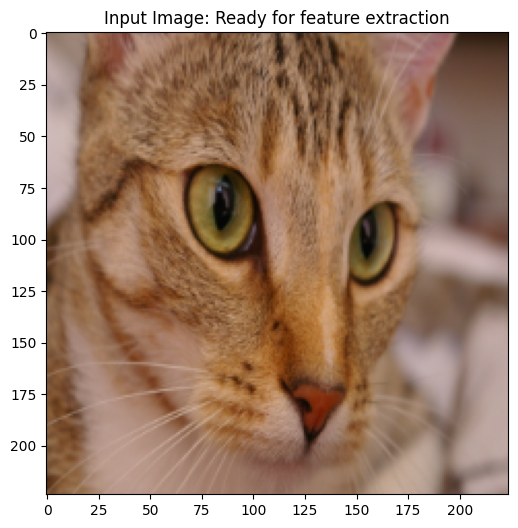

In [13]:
img_raw = data.cat()
img_raw = transform.resize(img_raw, (224, 224))

plt.figure(figsize = (8, 6))
plt.imshow(img_raw)
plt.title("Input Image: Ready for feature extraction")
plt.show()

In [14]:
img_raw

array([[[0.56196279, 0.47176671, 0.40902161],
        [0.55434875, 0.46415267, 0.40140758],
        [0.55360766, 0.46341158, 0.40066648],
        ...,
        [0.18838552, 0.10634417, 0.05945354],
        [0.1862947 , 0.10889069, 0.05506316],
        [0.17709628, 0.10750598, 0.05127423]],

       [[0.57401157, 0.48558506, 0.42694467],
        [0.56506304, 0.47320065, 0.41598881],
        [0.56168215, 0.47138217, 0.40894877],
        ...,
        [0.18956941, 0.1126599 , 0.0637092 ],
        [0.18682323, 0.11298102, 0.05922663],
        [0.18702188, 0.11533726, 0.06257081]],

       [[0.58589973, 0.49955775, 0.44801585],
        [0.57576406, 0.48839734, 0.43708857],
        [0.57002875, 0.48293014, 0.4267081 ],
        ...,
        [0.19333238, 0.12246193, 0.07203234],
        [0.1919984 , 0.12052671, 0.07311404],
        [0.1955227 , 0.12374409, 0.08355583]],

       ...,

       [[0.31473284, 0.19470355, 0.09196371],
        [0.40900225, 0.28454223, 0.18988649],
        [0.47291163, 0

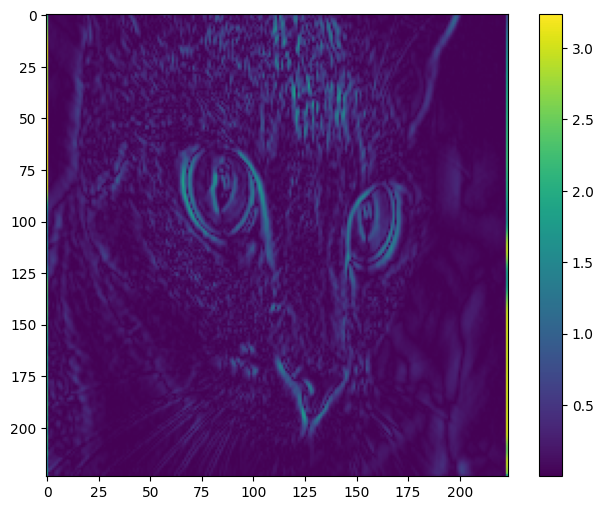

In [15]:
kernel = np.array([
    [-1,0,1],
    [-2,0,2],
    [-1,0,1]
])

from scipy.signal import convolve2d

feature_map = convolve2d(img_raw[:,:,0], kernel, mode = 'same')

plt.figure(figsize = (8, 6))
plt.imshow(np.absolute(feature_map), cmap="viridis")
plt.colorbar()
plt.show()

In [16]:
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from skimage import data, transform
import numpy as np
import matplotlib.pyplot as plt

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step


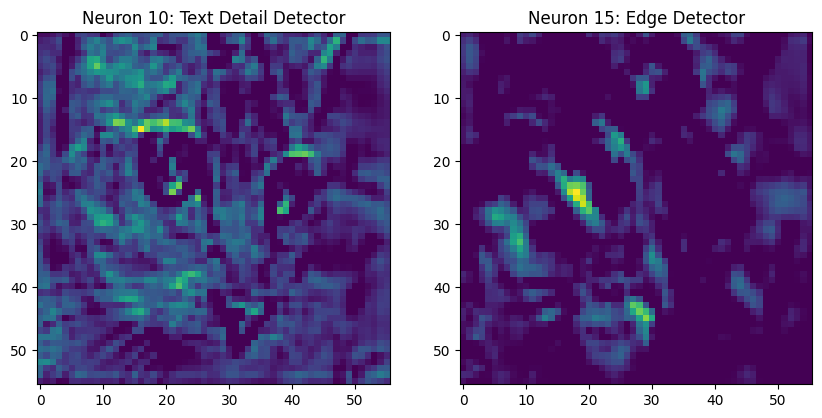

In [17]:
model  = VGG16(weights = 'imagenet', include_top = False)

img_raw = data.cat()
cat_resized = transform.resize(img_raw, (224, 224))
x = np.expand_dims(cat_resized*255, axis = 0)
x = preprocess_input(x)

mid_layer_model = tf.keras.Model(inputs = model.input, outputs = model.get_layer('block3_conv1').output)
mid_features = mid_layer_model.predict(x)

# Visualize the 10th and 15th filters (neurons)
fig, ax = plt.subplots(1, 2, figsize = (10, 10))
ax[0].imshow(mid_features[0, :, :, 10], cmap = 'viridis')
ax[0].set_title('Neuron 10: Text Detail Detector')
ax[1].imshow(mid_features[0, :, :, 15], cmap = 'viridis')
ax[1].set_title('Neuron 15: Edge Detector')
plt.show()

# Extract the final convolution layer (Block 5, Conv 3)

In [18]:
deep_layer_model = tf.keras.Model(inputs = model.input, outputs = model.get_layer('block5_conv3').output)

In [19]:
deep_features = deep_layer_model.predict(x)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 592ms/step


## In deep layers, many filters will be blank, but some will "glow" intensely
## On specific parts of the cat's image

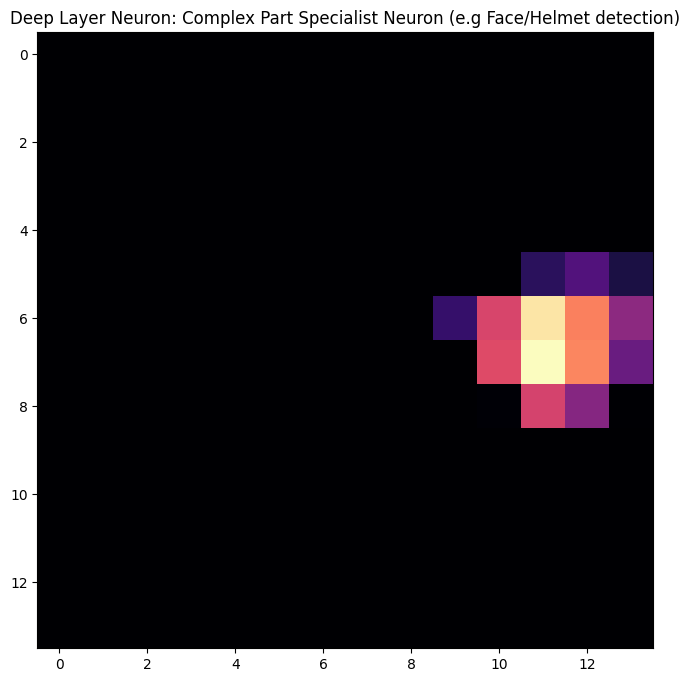

In [20]:
plt.figure(figsize= (8,8))
plt.imshow(deep_features[0, :, :, 1], cmap = 'magma')
plt.title('Deep Layer Neuron: Complex Part Specialist Neuron (e.g Face/Helmet detection)')
plt.show()